# Step 1. Preliminaries

## 1.1 Import Libraries (Run this)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from collections import defaultdict
import torch
import torch.nn as nn

import helpers 

# Configuration
DATA_DIR = 'CamelinaMAGIC-Dataset-Complete'
EXPERIMENTS = [1, 2, 3] # We will process all three
RANDOMIZATION_FILE = os.path.join(DATA_DIR, 'CamelinaMAGIC-ALL-Randomization.xlsx')

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


## 1.2 Loading Data and Processing (Run this)

Loading data from Experiments: [1, 2, 3]
  Processing Experiment 1...


/Users/williambushell/Documents/Uni Work/Fall 25/CMPT 878/CMPT 878 Project/helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()
/Users/williambushell/Documents/Uni Work/Fall 25/CMPT 878/CMPT 878 Project/helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()
/Users/williambushell/Documents/Uni Work/Fall 25/CMPT 878/CMPT 878 Project/helpers.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df_weather.resample(resample_freq, label="left", closed="left").mean()


  Processing Experiment 2...
  Processing Experiment 3...
Number of dataframes in the dict exp_transpiration_dataframes: 3


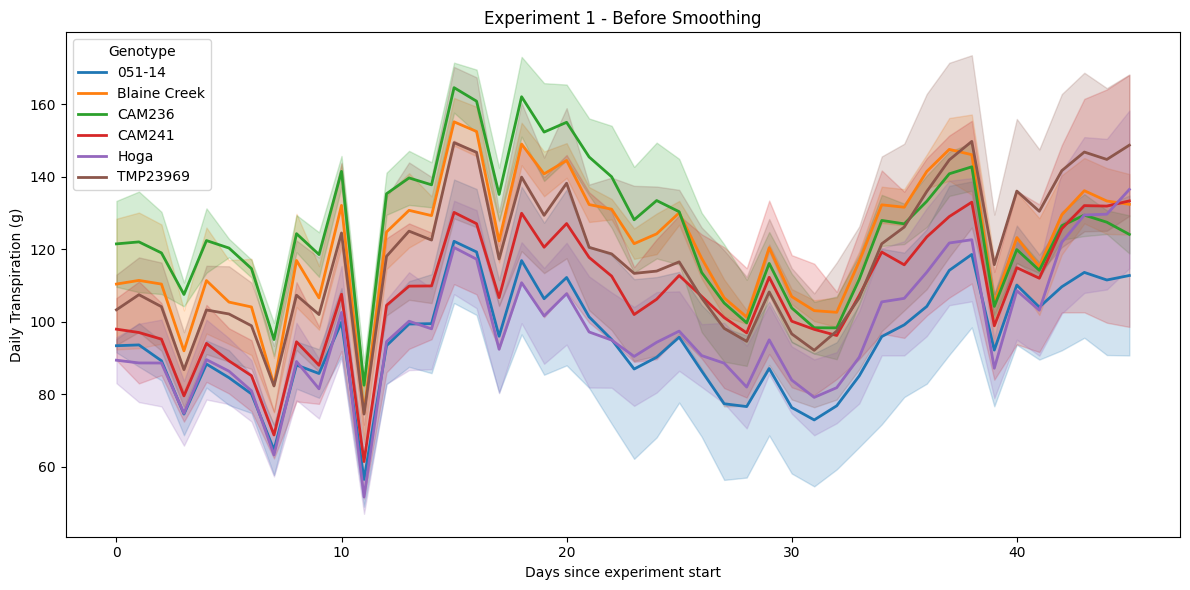

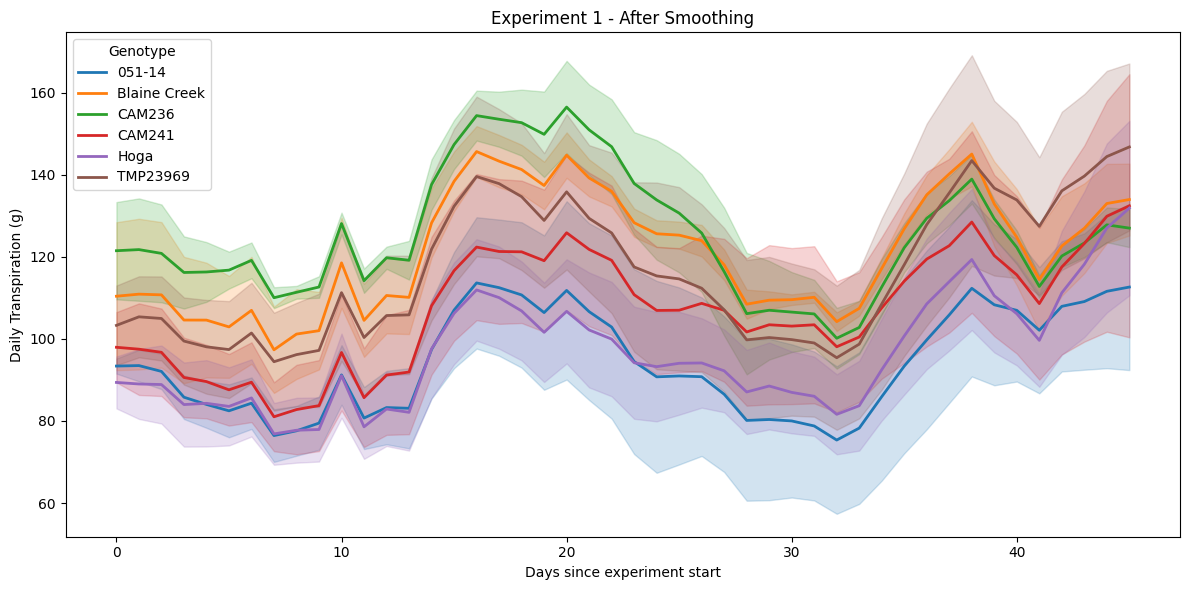

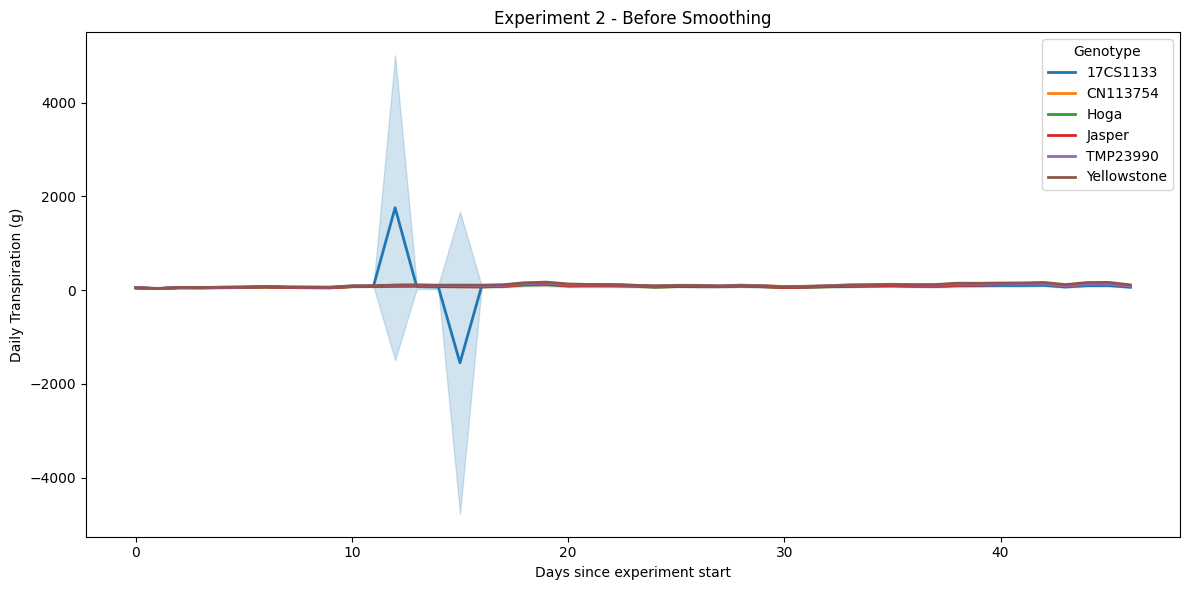

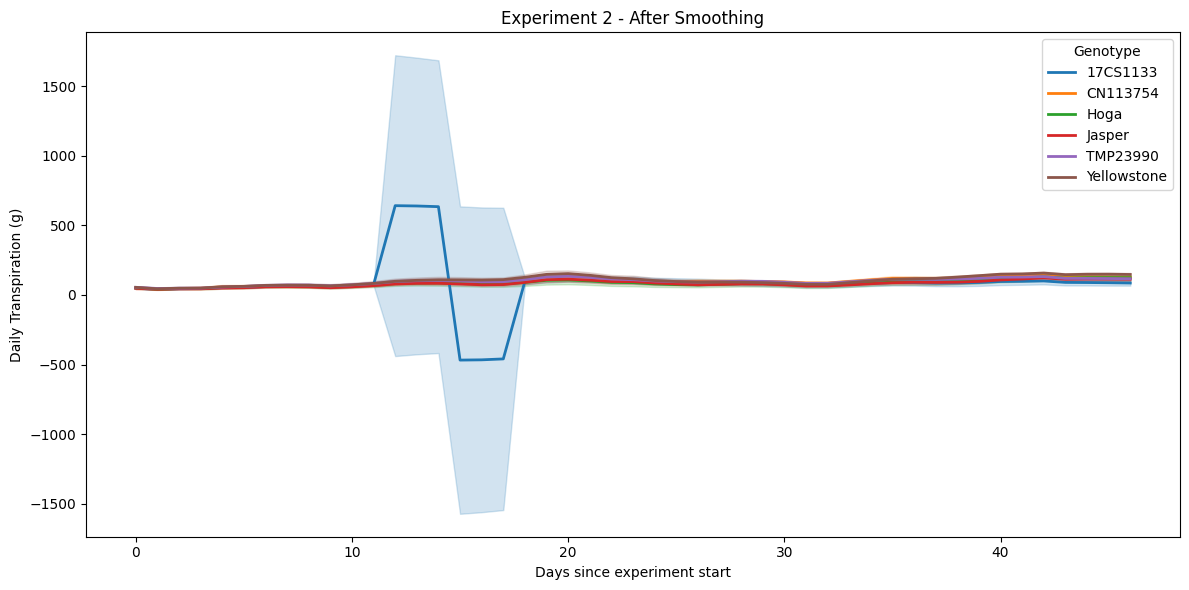

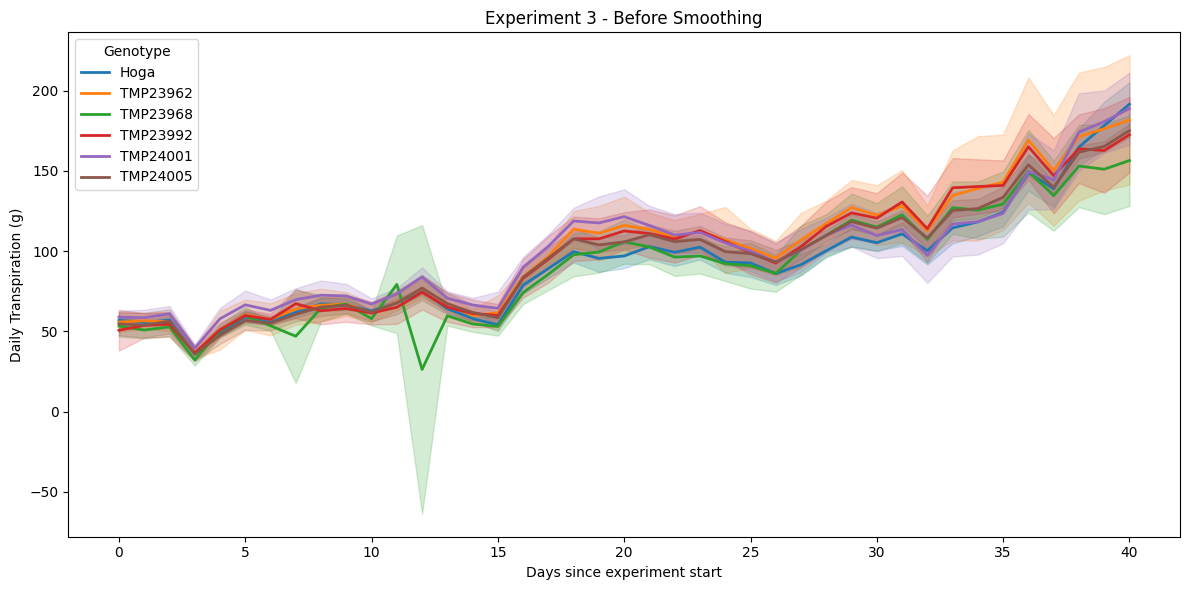

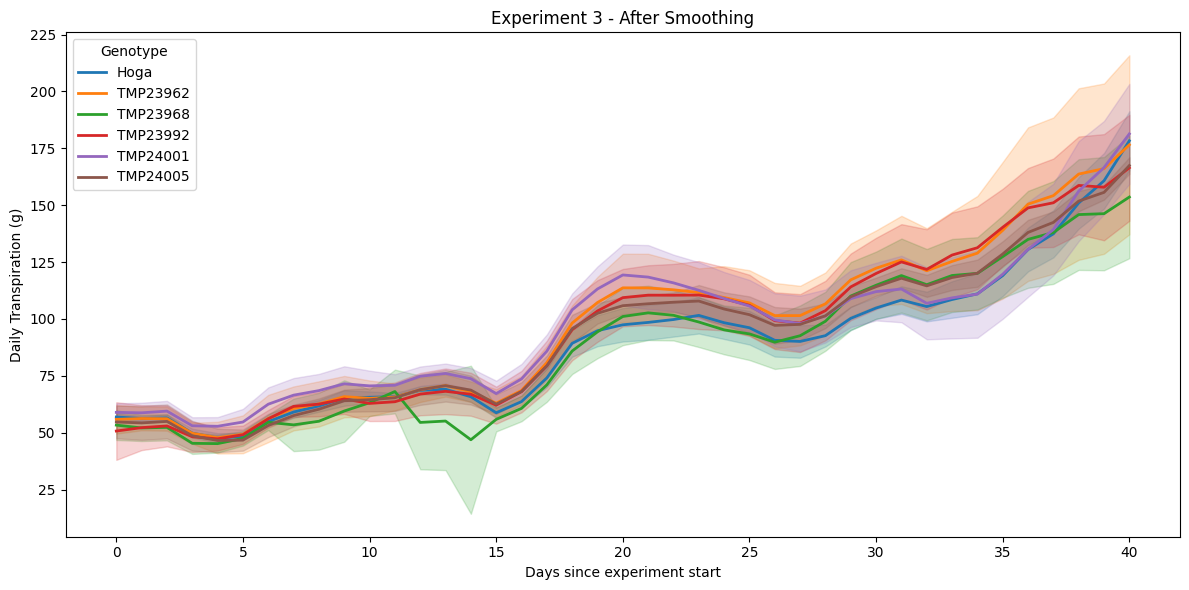

In [2]:
# 1.2 Data Loading and Processing


print("Loading data from Experiments:", EXPERIMENTS)

exp_transpiration_dataframes = {} # To store processed dataframes for each experiment

for exp_num in EXPERIMENTS:
    print(f"  Processing Experiment {exp_num}...")
    
    # 1. Define Paths
    transp_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-DailyTranspiration.csv')
    weather_file = os.path.join(DATA_DIR, f'CamelinaMAGIC{exp_num}.0-WeatherStation.csv')

    try:
        df_transp = helpers.read_transpiration_csv(transp_file, RANDOMIZATION_FILE, exp_num)
        df_weather = helpers.read_weather_station_csv(weather_file, exp_num)

    except Exception as e:
        print(f"    Skipping Exp {exp_num} due to error: {e}")
        continue

    df_transp = df_transp[df_transp['Treatment'] == 'DR_100']     # Filter for DROUGHT Only Plants
    #helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - Before VPD Normalization')

    helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - Before Smoothing')
    #print(f"df_transp before smoothing for Exp {exp_num}:\n", df_transp.head())
    
    df_transp['Transp_original'] = df_transp['Transpiration']  # Keep original for comparison


    # Smooth Data (Rolling Average)

    # cols_to_smooth = ['Weight', 'Transpiration', 'Transp_Norm'] #old line
    cols_to_smooth = ['Transpiration']
    df_transp['Transpiration'] = df_transp.groupby('Sample')[cols_to_smooth].transform(   # Group by Sample to ensure we don't smooth across different plants
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    helpers.plot_drought_transpiration_df(df_transp, title=f'Experiment {exp_num} - After Smoothing')
        
    #print(f"df_transp after smoothing for Exp {exp_num}:\n", df_transp.head())

    exp_transpiration_dataframes[exp_num] = df_transp # Store for later use.

print("Number of dataframes in the dict exp_transpiration_dataframes:", len(exp_transpiration_dataframes))



### Just to visualize important information for now (Skip)

In [3]:
combined_df = pd.concat([d for d in exp_transpiration_dataframes.values()], ignore_index=True)

unique_samples = combined_df['Sample'].unique()
print(f"  Found \033[32m\033[1m{len(unique_samples)}\033[0m\033[m unique samples in all the experiments combined:\n ", unique_samples, "\n")

unique_genotypes = combined_df['Genotype'].unique()
print(f"  Found \033[32m\033[1m{len(unique_genotypes)}\033[0m\033[m unique genotypes in all the experiments combined:\n ", unique_genotypes, "\n")


for exp, df in exp_transpiration_dataframes.items():
    unique_exp_samples = df['Sample'].unique()
    print(f"  Found \033[32m\033[1m{len(unique_exp_samples)}\033[0m\033[m unique samples in experiment \033[32m\033[1m{exp}\033[0m\033[m:\n ", unique_exp_samples, "\n")
    
    unique_exp_genotypes = df['Genotype'].unique()
    print(f"  Found \033[32m\033[1m{len(unique_exp_genotypes)}\033[0m\033[m unique genotypes in experiment \033[32m\033[1m{exp}\033[0m\033[m:\n ", unique_exp_genotypes, "\n")


  Found 35 unique samples in all the experiments combined:
  ['Camelina06' 'Camelina07' 'Camelina08' 'Camelina09' 'Camelina10'
 'Camelina15' 'Camelina16' 'Camelina17' 'Camelina18' 'Camelina23'
 'Camelina24' 'Camelina25' 'Camelina26' 'Camelina31' 'Camelina32'
 'Camelina33' 'Camelina34' 'Camelina39' 'Camelina40' 'Camelina41'
 'Camelina42' 'Camelina47' 'Camelina48' 'Camelina49' 'Camelina50'
 'Camelina05' 'Camelina13' 'Camelina14' 'Camelina21' 'Camelina22'
 'Camelina29' 'Camelina30' 'Camelina37' 'Camelina38' 'Camelina46'] 

  Found 16 unique genotypes in all the experiments combined:
  ['Hoga' 'Blaine Creek' 'TMP23969' '051-14' 'CAM236' 'CAM241' 'Yellowstone'
 '17CS1133' 'CN113754' 'Jasper' 'TMP23990' 'TMP24001' 'TMP24005'
 'TMP23962' 'TMP23992' 'TMP23968'] 

  Found 25 unique samples in experiment 1:
  ['Camelina06' 'Camelina07' 'Camelina08' 'Camelina09' 'Camelina10'
 'Camelina15' 'Camelina16' 'Camelina17' 'Camelina18' 'Camelina23'
 'Camelina24' 'Camelina25' 'Camelina26' 'Camelina31' 'Cam

### Prepare Unified Dataset with All Samples (Run This)

In [4]:
# Prepare unified dataset: pool all samples across all experiments and genotypes
# Each sample will have: [11 transpiration values, 16 genotype one-hot features, 3 experiment one-hot features]

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np
import pandas as pd

INPUT_WINDOW = list(range(15, 26))   # Days 15-25 inclusive (11 timesteps)
RECOVERY_WINDOW = list(range(36, 41)) # Days 36-40 inclusive

print("Building unified dataset from all experiments and genotypes...")

# Collect all samples with their features and targets
all_samples_data = []

for exp in [1, 2, 3]:
    exp_df = exp_transpiration_dataframes.get(exp)
    if exp_df is None:
        continue
    
    # Group by sample to process each plant individually
    for sample_name, sample_df in exp_df.groupby('Sample'):
        sample_df_sorted = sample_df.sort_values('Days')
        
        # Get input window data (Days 15-25) - SMOOTHED transpiration
        input_data = sample_df_sorted[sample_df_sorted['Days'].isin(INPUT_WINDOW)]
        if len(input_data) < len(INPUT_WINDOW):
            continue  # Skip samples with incomplete input data
        
        # Extract SMOOTHED transpiration values for input window
        transp_features = input_data['Transpiration'].values  # Already smoothed in Cell 5
        
        # Get genotype
        genotype = sample_df['Genotype'].iloc[0]
        
        # Calculate target slope from recovery window (Days 36-40) - SMOOTHED data
        recovery_data = sample_df_sorted[sample_df_sorted['Days'].isin(RECOVERY_WINDOW)]
        if len(recovery_data) < 2:
            continue  # Skip samples without enough recovery data
        
        from scipy.stats import linregress
        target_slope = float(linregress(recovery_data['Days'], recovery_data['Transpiration']).slope)
        
        # Store all information
        all_samples_data.append({
            'Sample': sample_name,
            'Experiment': exp,
            'Genotype': genotype,
            'Transpiration_Features': transp_features,
            'Target_Slope': target_slope
        })

print(f"✓ Collected {len(all_samples_data)} samples total")

# Create feature matrix with one-hot encoded genotypes and experiments
unique_genotypes = sorted(list(set([s['Genotype'] for s in all_samples_data])))
print(f"✓ Found {len(unique_genotypes)} unique genotypes: {unique_genotypes}")

# Build feature matrix WITH ONE-HOT EXPERIMENTS
X_unified = []
y_unified = []
sample_info = []  # Keep track of sample metadata

for sample_data in all_samples_data:
    # Start with SMOOTHED transpiration features (11 values)
    features = list(sample_data['Transpiration_Features'])
    
    # Add one-hot encoded genotype (16 features)
    genotype_encoding = [1 if g == sample_data['Genotype'] else 0 for g in unique_genotypes]
    features.extend(genotype_encoding)
    
    # Add one-hot encoded experiment (3 features)
    exp_encoding = [1 if exp == sample_data['Experiment'] else 0 for exp in [1, 2, 3]]
    features.extend(exp_encoding)
    
    X_unified.append(features)
    y_unified.append(sample_data['Target_Slope'])
    sample_info.append({
        'Sample': sample_data['Sample'],
        'Experiment': sample_data['Experiment'],
        'Genotype': sample_data['Genotype']
    })

X_unified = np.array(X_unified)
y_unified = np.array(y_unified)

print(f"\n{'='*70}")
print(f"UNIFIED DATASET SUMMARY")
print(f"{'='*70}")
print(f"Total samples: {len(X_unified)}")
print(f"Feature dimensions: {X_unified.shape[1]} features")
print(f"  - Transpiration SMOOTHED (Days 15-25): 11 features")
print(f"  - Genotype (one-hot): {len(unique_genotypes)} features")
print(f"  - Experiment (one-hot): 3 features")
print(f"Target: Recovery slope from SMOOTHED data (Days 36-40)")
print(f"Target range: [{y_unified.min():.4f}, {y_unified.max():.4f}]")
print(f"Target mean: {y_unified.mean():.4f}")
print(f"Target std: {y_unified.std():.4f}")
print(f"{'='*70}\n")


Building unified dataset from all experiments and genotypes...
✓ Collected 76 samples total
✓ Found 16 unique genotypes: ['051-14', '17CS1133', 'Blaine Creek', 'CAM236', 'CAM241', 'CN113754', 'Hoga', 'Jasper', 'TMP23962', 'TMP23968', 'TMP23969', 'TMP23990', 'TMP23992', 'TMP24001', 'TMP24005', 'Yellowstone']

UNIFIED DATASET SUMMARY
Total samples: 76
Feature dimensions: 30 features
  - Transpiration SMOOTHED (Days 15-25): 11 features
  - Genotype (one-hot): 16 features
  - Experiment (one-hot): 3 features
Target: Recovery slope from SMOOTHED data (Days 36-40)
Target range: [-4.6503, 14.8983]
Target mean: 3.9402
Target std: 4.4983



# Train Models on Original Dataset and Evaluate (No need to run)

In [5]:
# Train unified models using LOOCV on all samples
# Models: Linear Regression, Random Forest, LSTM
# Each model trains 76 times (once per sample), training on 75 and testing on 1
# Final metrics are computed by averaging performance across all 76 test samples

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import numpy as np
import os
import pickle

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create models directory
MODELS_DIR = 'models'
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

print(f"Training unified models with LOOCV on {len(X_unified)} samples...")
print(f"Each fold: Train on {len(X_unified)-1} samples, Test on 1 sample")
print(f"Total folds: {len(X_unified)}\n")

# ============================================================================
# 1. LINEAR REGRESSION
# ============================================================================
print("="*70)
print("LINEAR REGRESSION")
print("="*70)


loo = LeaveOneOut()
lr_preds = []
lr_actuals = []
lr_sample_info = []

from sklearn.linear_model import Ridge

for train_idx, test_idx in loo.split(X_unified):
    X_train, X_test = X_unified[train_idx], X_unified[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Linear Regression model
    model = lr = Ridge(alpha=10.0)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)[0]
    
    lr_preds.append(y_pred)
    lr_actuals.append(y_test[0])
    lr_sample_info.append(sample_info[test_idx[0]])

# Calculate metrics by comparing all 76 predictions to actual values
lr_r2 = r2_score(lr_actuals, lr_preds)
lr_mse = mean_squared_error(lr_actuals, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(lr_actuals, lr_preds)

print(f"R² Score: {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE: {lr_mae:.4f}")

# Train final model on all data for deployment
scaler_final_lr = StandardScaler()
X_scaled_final = scaler_final_lr.fit_transform(X_unified)
final_model_lr = LinearRegression()
final_model_lr.fit(X_scaled_final, y_unified)

# Save model
lr_model_path = os.path.join(MODELS_DIR, 'LR_unified_model.pkl')
lr_scaler_path = os.path.join(MODELS_DIR, 'LR_unified_scaler.pkl')
with open(lr_model_path, 'wb') as f:
    pickle.dump(final_model_lr, f)
with open(lr_scaler_path, 'wb') as f:
    pickle.dump(scaler_final_lr, f)
print(f"✓ Saved: {lr_model_path}")
print(f"✓ Saved: {lr_scaler_path}\n")

# ============================================================================
# 2. RANDOM FOREST
# ============================================================================
print("="*70)
print("RANDOM FOREST")
print("="*70)

rf_preds = []
rf_actuals = []

for train_idx, test_idx in loo.split(X_unified):
    X_train, X_test = X_unified[train_idx], X_unified[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Scale features for consistency
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=2)
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)[0]
    
    rf_preds.append(y_pred)
    rf_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
rf_r2 = r2_score(rf_actuals, rf_preds)
rf_mse = mean_squared_error(rf_actuals, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(rf_actuals, rf_preds)

print(f"R² Score: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE: {rf_mae:.4f}")

# Train final model on all data for deployment
scaler_final_rf = StandardScaler()
X_scaled_final_rf = scaler_final_rf.fit_transform(X_unified)
final_model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_leaf=2)
final_model_rf.fit(X_scaled_final_rf, y_unified)

# Save model
rf_model_path = os.path.join(MODELS_DIR, 'RF_unified_model.pkl')
rf_scaler_path = os.path.join(MODELS_DIR, 'RF_unified_scaler.pkl')
with open(rf_model_path, 'wb') as f:
    pickle.dump(final_model_rf, f)
with open(rf_scaler_path, 'wb') as f:
    pickle.dump(scaler_final_rf, f)
print(f"✓ Saved: {rf_model_path}")
print(f"✓ Saved: {rf_scaler_path}\n")

# ============================================================================
# 3. LSTM (PyTorch)
# ============================================================================
print("="*70)
print("LSTM")
print("="*70)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Combine LSTM output with metadata features
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        lstm_out, _ = self.lstm(x_sequence)
        lstm_out = lstm_out[:, -1, :]  # Take last timestep
        
        # Concatenate with metadata
        combined = torch.cat((lstm_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Prepare data for LSTM: separate time-series from metadata
X_sequence = X_unified[:, :11].reshape(-1, 11, 1)  # SMOOTHED Transpiration
X_metadata = X_unified[:, 11:]  # Genotype (16) + Experiment (3) = 19

lstm_preds = []
lstm_actuals = []

print("Training LSTM (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(800):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    lstm_preds.append(y_pred)
    lstm_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
lstm_r2 = r2_score(lstm_actuals, lstm_preds)
lstm_mse = mean_squared_error(lstm_actuals, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(lstm_actuals, lstm_preds)

print(f"R² Score: {lstm_r2:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE: {lstm_mae:.4f}")

# Train final LSTM model on all data for deployment
print("Training final LSTM model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_lstm = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_lstm.parameters(), lr=0.01)

final_model_lstm.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = final_model_lstm(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save LSTM model
lstm_model_path = os.path.join(MODELS_DIR, 'LSTM_unified_model.pth')
torch.save(final_model_lstm.state_dict(), lstm_model_path)
print(f"✓ Saved: {lstm_model_path}\n")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'R²': [lr_r2, rf_r2, lstm_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae],
    'Samples': [len(X_unified)] * 3,
    'Features': [X_unified.shape[1]] * 3
})

display(results_df.sort_values('R²', ascending=False).reset_index(drop=True))


Training unified models with LOOCV on 76 samples...
Each fold: Train on 75 samples, Test on 1 sample
Total folds: 76

LINEAR REGRESSION
R² Score: -9.2528
RMSE: 14.4036
MAE: 3.5331
✓ Saved: models/LR_unified_model.pkl
✓ Saved: models/LR_unified_scaler.pkl

RANDOM FOREST
R² Score: 0.6903
RMSE: 2.5034
MAE: 2.0226
✓ Saved: models/RF_unified_model.pkl
✓ Saved: models/RF_unified_scaler.pkl

LSTM
Training LSTM (this may take a few minutes)...
  Fold 10/76
  Fold 20/76
  Fold 30/76
  Fold 40/76
  Fold 50/76
  Fold 60/76
  Fold 70/76
R² Score: 0.7428
RMSE: 2.2811
MAE: 1.8192
Training final LSTM model...
✓ Saved: models/LSTM_unified_model.pth

MODEL COMPARISON SUMMARY


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.742843,2.281136,1.819182,76,30
1,Random Forest,0.690299,2.503358,2.022608,76,30
2,Linear Regression,-9.252754,14.403637,3.533078,76,30


## GRU Model (Run this)

In [6]:
1# ============================================================================
# 4. GRU (PyTorch) - New Model
# ============================================================================
print("="*70)
print("GRU")
print("="*70)
MODELS_DIR = 'models'
# Define GRU model (similar architecture to LSTM)
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        # Combine GRU output with metadata features
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        gru_out, _ = self.gru(x_sequence)
        gru_out = gru_out[:, -1, :]  # Take last timestep
        
        # Concatenate with metadata
        combined = torch.cat((gru_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Use same data preparation as LSTM (already defined as X_sequence and X_metadata)
gru_preds = []
gru_actuals = []

print("Training GRU (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(800):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    gru_preds.append(y_pred)
    gru_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
gru_r2 = r2_score(gru_actuals, gru_preds)
gru_mse = mean_squared_error(gru_actuals, gru_preds)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(gru_actuals, gru_preds)

print(f"R² Score: {gru_r2:.4f}")
print(f"RMSE: {gru_rmse:.4f}")
print(f"MAE: {gru_mae:.4f}")

# Train final GRU model on all data for deployment
print("Training final GRU model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_gru = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_gru.parameters(), lr=0.01)

final_model_gru.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = final_model_gru(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save GRU model
gru_model_path = os.path.join(MODELS_DIR, 'GRU_unified_model.pth')
torch.save(final_model_gru.state_dict(), gru_model_path)
print(f"✓ Saved: {gru_model_path}\n")

# ============================================================================
# UPDATED SUMMARY TABLE (with GRU)
# ============================================================================
print("="*70)
print("MODEL COMPARISON SUMMARY (UPDATED WITH GRU)")
print("="*70)

results_df_updated = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM', 'GRU'],
    'R²': [lr_r2, rf_r2, lstm_r2, gru_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae, gru_mae],
    'Samples': [len(X_unified)] * 4,
    'Features': [X_unified.shape[1]] * 4
})

display(results_df_updated.sort_values('R²', ascending=False).reset_index(drop=True))

GRU
Training GRU (this may take a few minutes)...
  Fold 10/76
  Fold 20/76
  Fold 30/76
  Fold 40/76
  Fold 50/76
  Fold 60/76
  Fold 70/76
R² Score: 0.6944
RMSE: 2.4866
MAE: 1.9941
Training final GRU model...
✓ Saved: models/GRU_unified_model.pth

MODEL COMPARISON SUMMARY (UPDATED WITH GRU)


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.742843,2.281136,1.819182,76,30
1,GRU,0.694439,2.486571,1.994105,76,30
2,Random Forest,0.690299,2.503358,2.022608,76,30
3,Linear Regression,-9.252754,14.403637,3.533078,76,30


## Bidirectional LSTM Model (Run this)

In [7]:
# ============================================================================
# 5. BIDIRECTIONAL LSTM (PyTorch)
# ============================================================================
print("="*70)
print("BIDIRECTIONAL LSTM")
print("="*70)

# Define Bidirectional LSTM model
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(BiLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Bidirectional LSTM: outputs hidden_size * 2
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        # Combine BiLSTM output (hidden_size*2) with metadata features
        self.fc1 = nn.Linear(hidden_size * 2 + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_sequence, x_metadata):
        # x_sequence: (batch, seq_len, features) = (batch, 11, 1)
        # x_metadata: (batch, metadata_features) = (batch, 19) for genotype+experiment
        
        lstm_out, _ = self.lstm(x_sequence)
        lstm_out = lstm_out[:, -1, :]  # Take last timestep (contains both forward and backward)
        
        # Concatenate with metadata
        combined = torch.cat((lstm_out, x_metadata), dim=1)
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        output = self.fc2(x)
        return output

# Use same data preparation as LSTM (already defined as X_sequence and X_metadata)
bilstm_preds = []
bilstm_actuals = []

print("Training Bidirectional LSTM (this may take a few minutes)...")
for fold_num, (train_idx, test_idx) in enumerate(loo.split(X_unified), 1):
    if fold_num % 10 == 0:
        print(f"  Fold {fold_num}/{len(X_unified)}")
    
    X_seq_train, X_seq_test = X_sequence[train_idx], X_sequence[test_idx]
    X_meta_train, X_meta_test = X_metadata[train_idx], X_metadata[test_idx]
    y_train, y_test = y_unified[train_idx], y_unified[test_idx]
    
    # Convert to PyTorch tensors
    X_seq_train_t = torch.FloatTensor(X_seq_train)
    X_meta_train_t = torch.FloatTensor(X_meta_train)
    y_train_t = torch.FloatTensor(y_train)
    X_seq_test_t = torch.FloatTensor(X_seq_test)
    X_meta_test_t = torch.FloatTensor(X_meta_test)
    
    # Initialize model
    model = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # Train
    model.train()
    for epoch in range(800):
        optimizer.zero_grad()
        outputs = model(X_seq_train_t, X_meta_train_t)
        loss = criterion(outputs.squeeze(), y_train_t)
        loss.backward()
        optimizer.step()
    
    # Predict
    model.eval()
    with torch.no_grad():
        y_pred = model(X_seq_test_t, X_meta_test_t).item()
    
    bilstm_preds.append(y_pred)
    bilstm_actuals.append(y_test[0])

# Calculate metrics by comparing all 76 predictions to actual values
bilstm_r2 = r2_score(bilstm_actuals, bilstm_preds)
bilstm_mse = mean_squared_error(bilstm_actuals, bilstm_preds)
bilstm_rmse = np.sqrt(bilstm_mse)
bilstm_mae = mean_absolute_error(bilstm_actuals, bilstm_preds)

print(f"R² Score: {bilstm_r2:.4f}")
print(f"RMSE: {bilstm_rmse:.4f}")
print(f"MAE: {bilstm_mae:.4f}")

# Train final Bidirectional LSTM model on all data for deployment
print("Training final Bidirectional LSTM model...")
X_seq_all = torch.FloatTensor(X_sequence)
X_meta_all = torch.FloatTensor(X_metadata)
y_all = torch.FloatTensor(y_unified)

final_model_bilstm = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_model_bilstm.parameters(), lr=0.01)

final_model_bilstm.train()
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = final_model_bilstm(X_seq_all, X_meta_all)
    loss = criterion(outputs.squeeze(), y_all)
    loss.backward()
    optimizer.step()

# Save Bidirectional LSTM model
bilstm_model_path = os.path.join(MODELS_DIR, 'BiLSTM_unified_model.pth')
torch.save(final_model_bilstm.state_dict(), bilstm_model_path)
print(f"✓ Saved: {bilstm_model_path}\n")

# ============================================================================
# FINAL SUMMARY TABLE (with all models)
# ============================================================================
print("="*70)
print("COMPLETE MODEL COMPARISON SUMMARY")
print("="*70)

results_df_complete = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM', 'GRU', 'Bidirectional LSTM'],
    'R²': [lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse, bilstm_rmse],
    'MAE': [lr_mae, rf_mae, lstm_mae, gru_mae, bilstm_mae],
    'Samples': [len(X_unified)] * 5,
    'Features': [X_unified.shape[1]] * 5
})

display(results_df_complete.sort_values('R²', ascending=False).reset_index(drop=True))

BIDIRECTIONAL LSTM
Training Bidirectional LSTM (this may take a few minutes)...
  Fold 10/76
  Fold 20/76
  Fold 30/76
  Fold 40/76
  Fold 50/76
  Fold 60/76
  Fold 70/76
R² Score: 0.7119
RMSE: 2.4143
MAE: 1.9646
Training final Bidirectional LSTM model...
✓ Saved: models/BiLSTM_unified_model.pth

COMPLETE MODEL COMPARISON SUMMARY


,Model,R²,RMSE,MAE,Samples,Features
0,LSTM,0.742843,2.281136,1.819182,76,30
1,Bidirectional LSTM,0.711949,2.414275,1.964621,76,30
2,GRU,0.694439,2.486571,1.994105,76,30
3,Random Forest,0.690299,2.503358,2.022608,76,30
4,Linear Regression,-9.252754,14.403637,3.533078,76,30


# Generate first Augmented set (Run this)

In [8]:
# ============================================================================
# DATA AUGMENTATION
# ============================================================================
print("="*70)
print("DATA AUGMENTATION")
print("="*70)

import numpy as np
from copy import deepcopy

# Set seed for reproducibility
np.random.seed(42)

# Augmentation parameters
AUGMENTATIONS_PER_SAMPLE = 3  # Generate 3 augmented versions per original sample
SCALE_RANGE = (0.85, 1.15)    # Random scaling factor range (±15%)
JITTER_STD = 0.02              # Standard deviation for Gaussian jitter (2% of mean)
MIX_PROBABILITY = 0.3          # 30% chance to mix with another sample of same genotype

print(f"Original dataset: {len(X_unified)} samples")
print(f"Augmentations per sample: {AUGMENTATIONS_PER_SAMPLE}")
print(f"Expected augmented dataset size: {len(X_unified) * (1 + AUGMENTATIONS_PER_SAMPLE)} samples\n")

# Store augmented data
X_augmented_list = []
y_augmented_list = []
sample_info_augmented_list = []

# First, add all original samples
for i in range(len(X_unified)):
    X_augmented_list.append(X_unified[i].copy())
    y_augmented_list.append(y_unified[i])
    sample_info_augmented_list.append(deepcopy(sample_info[i]))

# Group samples by genotype for pattern mixing
genotype_groups = {}
for idx, info in enumerate(sample_info):
    genotype = info['Genotype']
    if genotype not in genotype_groups:
        genotype_groups[genotype] = []
    genotype_groups[genotype].append(idx)

print("Generating augmented samples...")
augmentation_count = 0

for original_idx in range(len(X_unified)):
    original_x = X_unified[original_idx].copy()
    original_y = y_unified[original_idx]
    original_info = sample_info[original_idx]
    genotype = original_info['Genotype']
    
    # Extract time series (Days 15-25) and metadata separately
    time_series = original_x[:11]  # Transpiration values
    metadata = original_x[11:]     # Genotype + Experiment one-hot (16 + 3 = 19)
    
    for aug_num in range(AUGMENTATIONS_PER_SAMPLE):
        augmented_time_series = time_series.copy()
        augmented_y = original_y
        
        # Augmentation 1: Random Scaling
        # Scale the time series while maintaining relative patterns
        scale_factor = np.random.uniform(*SCALE_RANGE)
        augmented_time_series = augmented_time_series * scale_factor
        augmented_y = augmented_y * scale_factor  # Scale target proportionally
        
        # Augmentation 2: Random Jitter
        # Add small Gaussian noise to simulate measurement variations
        mean_val = np.mean(np.abs(augmented_time_series))
        jitter = np.random.normal(0, mean_val * JITTER_STD, size=augmented_time_series.shape)
        augmented_time_series = augmented_time_series + jitter

        # Augmentation 3: Pattern Mixing (with same genotype only)
        # Blend with another sample of the same genotype to create hybrid patterns
        if np.random.random() < MIX_PROBABILITY and len(genotype_groups[genotype]) > 1:
            # Select a different sample from the same genotype
            same_genotype_indices = [idx for idx in genotype_groups[genotype] if idx != original_idx]
            if same_genotype_indices:
                mix_idx = np.random.choice(same_genotype_indices)
                mix_time_series = X_unified[mix_idx][:11]
                mix_y = y_unified[mix_idx]
                
                # Blend with random weight (70-30 to 30-70)
                mix_weight = np.random.uniform(0.3, 0.7)
                augmented_time_series = (1 - mix_weight) * augmented_time_series + mix_weight * mix_time_series
                augmented_y = (1 - mix_weight) * augmented_y + mix_weight * mix_y
        
        # Ensure no negative values (transpiration cannot be negative)
        augmented_time_series = np.maximum(augmented_time_series, 0)
        
        # Combine augmented time series with original metadata
        augmented_x = np.concatenate([augmented_time_series, metadata])
        
        # Add to augmented dataset
        X_augmented_list.append(augmented_x)
        y_augmented_list.append(augmented_y)
        
        # Create augmented sample info with marker
        augmented_info = deepcopy(original_info)
        augmented_info['Sample'] = f"{original_info['Sample']}_aug{aug_num+1}"
        sample_info_augmented_list.append(augmented_info)
        
        augmentation_count += 1

# Convert to numpy arrays
X_unified_augmented = np.array(X_augmented_list)
y_unified_augmented = np.array(y_augmented_list)
sample_info_augmented = sample_info_augmented_list

print(f"✓ Generated {augmentation_count} new augmented samples")
print(f"\n{'='*70}")
print(f"AUGMENTED DATASET SUMMARY")
print(f"{'='*70}")
print(f"Original samples: {len(X_unified)}")
print(f"Augmented samples: {len(X_unified_augmented)}")
print(f"Increase: {len(X_unified_augmented) / len(X_unified):.1f}x")
print(f"Feature dimensions: {X_unified_augmented.shape[1]} features (unchanged)")
print(f"Target range: [{y_unified_augmented.min():.4f}, {y_unified_augmented.max():.4f}]")
print(f"Target mean: {y_unified_augmented.mean():.4f} (original: {y_unified.mean():.4f})")
print(f"Target std: {y_unified_augmented.std():.4f} (original: {y_unified.std():.4f})")
print(f"{'='*70}\n")

print("To use augmented data in training cells, replace:")
print("  X_unified → X_unified_augmented")
print("  y_unified → y_unified_augmented")
print("  sample_info → sample_info_augmented")

DATA AUGMENTATION
Original dataset: 76 samples
Augmentations per sample: 3
Expected augmented dataset size: 304 samples

Generating augmented samples...
✓ Generated 228 new augmented samples

AUGMENTED DATASET SUMMARY
Original samples: 76
Augmented samples: 304
Increase: 4.0x
Feature dimensions: 30 features (unchanged)
Target range: [-5.1944, 15.5984]
Target mean: 3.9175 (original: 3.9402)
Target std: 4.3683 (original: 4.4983)

To use augmented data in training cells, replace:
  X_unified → X_unified_augmented
  y_unified → y_unified_augmented
  sample_info → sample_info_augmented


# Augmented Data training and Model Comparison (Run this)

In [9]:
# ============================================================================
# 6. ALL MODELS ON AUGMENTED DATA + COMPARISON WITH ORIGINAL RESULTS
# ============================================================================
print('='*70)
print('MODELS ON AUGMENTED DATA (LOOCV)')
print('='*70)

# Preconditions: Augmented variables must exist:
#   X_unified_augmented, y_unified_augmented, sample_info_augmented
# If not, abort gracefully.
needed_vars = ['X_unified_augmented', 'y_unified_augmented', 'sample_info_augmented']
for v in needed_vars:
    if v not in globals():
        raise RuntimeError(f"Augmented dataset variable '{v}' not found. Run the augmentation cell first.")

print(f"Original samples: {len(X_unified)} | Augmented samples: {len(X_unified_augmented)}")

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os

np.random.seed(42)
torch.manual_seed(42)

# --- Helper functions ---

def loocv_tabular_grouped(model_ctor, X, y, num_original_samples, scale=True):
    """
    Grouped LOOCV for augmented tabular data - prevents data leakage.
    Leaves out original + augmentations from training, but only tests on original.
    
    Parameters:
    - model_ctor: Function that returns a new model instance
    - X: Feature matrix (original + augmented samples)
    - y: Target vector (original + augmented samples)
    - num_original_samples: Number of original samples (before augmentation)
    - scale: Whether to apply StandardScaler
    
    Structure assumption: 
    - Indices 0 to (num_original_samples-1): Original samples
    - Indices num_original_samples onwards: Augmented samples (3 per original)
    
    Strategy:
    - Exclude from training: original + its 3 augmentations (4 samples)
    - Test only on: original sample (1 sample)
    - This prevents leakage while allowing fair performance reporting
    
    Returns:
    - r2, rmse, mae: Aggregate metrics
    - predictions_dict: Dictionary mapping sample_idx -> prediction value
    """
    preds, actuals = [], []
    predictions_dict = {}  # Store predictions indexed by sample
    
    # Create sample groups: [original_idx, aug1_idx, aug2_idx, aug3_idx]
    augmentations_per_sample = 3
    sample_groups = []
    for i in range(num_original_samples):
        group = [i]  # Original sample
        # Add its augmented versions
        for aug_num in range(augmentations_per_sample):
            aug_idx = num_original_samples + i * augmentations_per_sample + aug_num
            group.append(aug_idx)
        sample_groups.append(group)
    
    print(f'  Running Grouped LOOCV: {len(sample_groups)} groups')
    print(f'    - Exclude from training: 4 samples per fold (1 original + 3 augmentations)')
    print(f'    - Test on: 1 sample per fold (original only)')
    
    # Leave out one group at a time
    for group_idx, test_group in enumerate(sample_groups):
        if (group_idx + 1) % 10 == 0:
            print(f'    Progress: {group_idx + 1}/{len(sample_groups)} groups completed')
        
        # Exclude entire group from training (prevent leakage)
        exclude_idx = np.array(test_group)
        
        # Test only on original sample
        test_idx = np.array([test_group[0]])  # First element is original
        sample_idx = test_group[0]  # Store which sample this prediction is for
        
        # Train indices: all samples except excluded group
        train_idx = np.array([idx for i, group in enumerate(sample_groups) 
                              if i != group_idx for idx in group])
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        if scale:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
        
        model = model_ctor()
        model.fit(X_train, y_train)
        test_preds = model.predict(X_test)
        
        # Store prediction for this specific sample
        predictions_dict[sample_idx] = test_preds[0]
        
        preds.extend(test_preds.tolist())
        actuals.extend(y_test.tolist())
    
    r2 = r2_score(actuals, preds)
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae, predictions_dict

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.gru(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc1 = nn.Linear(hidden_size*2 + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

# --- Sequence LOOCV helper ---

def loocv_sequence_grouped(model_class, X_seq, X_meta, y, num_original_samples, hidden_size=64, num_layers=2, metadata_size=19, epochs=200, lr=0.01):
    """
    Grouped LOOCV for sequence models - prevents data leakage.
    
    Strategy:
    - Exclude from training: original + its 3 augmentations (4 samples)
    - Test only on: original sample (1 sample)
    - This prevents leakage while allowing fair performance reporting
    
    Returns:
    - r2, rmse, mae: Aggregate metrics
    - predictions_dict: Dictionary mapping sample_idx -> prediction value
    """
    preds, actuals = [], []
    predictions_dict = {}  # Store predictions indexed by sample
    criterion = nn.MSELoss()
    
    # Create sample groups: [original_idx, aug1_idx, aug2_idx, aug3_idx]
    augmentations_per_sample = 3
    sample_groups = []
    for i in range(num_original_samples):
        group = [i]  # Original sample
        # Add its augmented versions
        for aug_num in range(augmentations_per_sample):
            aug_idx = num_original_samples + i * augmentations_per_sample + aug_num
            group.append(aug_idx)
        sample_groups.append(group)
    
    print(f'  Running Grouped LOOCV: {len(sample_groups)} groups')
    print(f'    - Exclude from training: 4 samples per fold (1 original + 3 augmentations)')
    print(f'    - Test on: 1 sample per fold (original only)')
    
    # Grouped LOOCV: exclude entire group, test only on original
    for group_idx, test_group in enumerate(sample_groups):
        if (group_idx + 1) % 10 == 0:
            print(f'    Group {group_idx + 1}/{len(sample_groups)}')
        
        # Test only on original sample (prevent leakage, allow reporting)
        test_idx = np.array([test_group[0]])  # First element is original
        sample_idx = test_group[0]  # Store which sample this prediction is for
        
        # Train indices: all samples except excluded group
        train_idx = np.array([idx for i, group in enumerate(sample_groups) if i != group_idx for idx in group])
        
        X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
        X_meta_train, X_meta_test = X_meta[train_idx], X_meta[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        X_seq_train_t = torch.FloatTensor(X_seq_train)
        X_seq_test_t = torch.FloatTensor(X_seq_test)
        X_meta_train_t = torch.FloatTensor(X_meta_train)
        X_meta_test_t = torch.FloatTensor(X_meta_test)
        y_train_t = torch.FloatTensor(y_train)
        
        model = model_class(input_size=1, hidden_size=hidden_size, num_layers=num_layers, 
                           output_size=1, metadata_size=metadata_size)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        model.train()
        
        for _ in range(epochs):
            optimizer.zero_grad()
            out = model(X_seq_train_t, X_meta_train_t).squeeze()
            loss = criterion(out, y_train_t)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            test_preds = model(X_seq_test_t, X_meta_test_t).squeeze().numpy()
        
        # Store predictions for all samples in the test group
        if len(test_preds.shape) == 0:  # Single value
            pred_value = test_preds.item()
            test_preds = [pred_value]
        else:
            pred_value = test_preds[0]
            test_preds = test_preds.tolist()
        
        # Store prediction for this specific sample
        predictions_dict[sample_idx] = pred_value
            
        preds.extend(test_preds)
        actuals.extend(y_test.tolist())
    
    r2 = r2_score(actuals, preds)
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae, predictions_dict

# Prepare augmented sequence & metadata splits
X_sequence_aug = X_unified_augmented[:, :11].reshape(-1, 11, 1)
X_metadata_aug = X_unified_augmented[:, 11:]
y_aug = y_unified_augmented
metadata_size = X_metadata_aug.shape[1]

print('Running GROUPED LOOCV on augmented dataset (prevents data leakage)...')
print('⚠ NOTE: Using grouped validation - each fold leaves out 1 original + its 3 augmentations')
print('This prevents the model from seeing augmented versions of test samples during training.\n')

# Tabular models (use Ridge for linear robustness to augmented scaling)
print('Training tabular models (GROUPED LOOCV)...')
print('Linear Regression (Ridge):')
aug_lr_r2, aug_lr_rmse, aug_lr_mae, aug_lr_preds = loocv_tabular_grouped(lambda: Ridge(alpha=10.0), X_unified_augmented, y_aug, num_original_samples=len(X_unified), scale=True)
print('Random Forest:')
aug_rf_r2, aug_rf_rmse, aug_rf_mae, aug_rf_preds = loocv_tabular_grouped(lambda: RandomForestRegressor(n_estimators=120, random_state=42, max_depth=12, min_samples_leaf=2), X_unified_augmented, y_aug, num_original_samples=len(X_unified), scale=True)

# Sequence models - USE GROUPED LOOCV to prevent data leakage
SEQ_EPOCHS = 800 # Reduced per-fold epochs for efficiency on larger augmented set
print('\nTraining sequence models (GROUPED LOOCV)...')
print('LSTM:')
aug_lstm_r2, aug_lstm_rmse, aug_lstm_mae, aug_lstm_preds = loocv_sequence_grouped(LSTMModel, X_sequence_aug, X_metadata_aug, y_aug, num_original_samples=len(X_unified), metadata_size=metadata_size, epochs=SEQ_EPOCHS)
print('\nGRU:')
aug_gru_r2, aug_gru_rmse, aug_gru_mae, aug_gru_preds = loocv_sequence_grouped(GRUModel, X_sequence_aug, X_metadata_aug, y_aug, num_original_samples=len(X_unified), metadata_size=metadata_size, epochs=SEQ_EPOCHS)
print('\nBiLSTM:')
aug_bilstm_r2, aug_bilstm_rmse, aug_bilstm_mae, aug_bilstm_preds = loocv_sequence_grouped(BiLSTMModel, X_sequence_aug, X_metadata_aug, y_aug, num_original_samples=len(X_unified), metadata_size=metadata_size, epochs=SEQ_EPOCHS)

print('\nAugmented LOOCV complete.')

# Store all predictions for later analysis
augmented_loocv_predictions = {
    'Linear Regression (Ridge)': aug_lr_preds,
    'Random Forest': aug_rf_preds,
    'LSTM': aug_lstm_preds,
    'GRU': aug_gru_preds,
    'BiLSTM': aug_bilstm_preds
}
print('✓ Predictions saved for all models')

# Build comparison table (original metrics must exist from prior cells: lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Ridge)', 'Random Forest', 'LSTM', 'GRU', 'BiLSTM'],
    'R2_Original': [lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2],
    'RMSE_Original': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse, bilstm_rmse],
    'MAE_Original': [lr_mae, rf_mae, lstm_mae, gru_mae, bilstm_mae],
    'R2_Augmented': [aug_lr_r2, aug_rf_r2, aug_lstm_r2, aug_gru_r2, aug_bilstm_r2],
    'RMSE_Augmented': [aug_lr_rmse, aug_rf_rmse, aug_lstm_rmse, aug_gru_rmse, aug_bilstm_rmse],
    'MAE_Augmented': [aug_lr_mae, aug_rf_mae, aug_lstm_mae, aug_gru_mae, aug_bilstm_mae],
    'Original_Samples': [len(X_unified)]*5,
    'Augmented_Samples': [len(X_unified_augmented)]*5
})

print('\n' + '='*70)
print('ORIGINAL vs AUGMENTED DATASET PERFORMANCE')
print('='*70)
from IPython.display import display

# Add improvement column
comparison_df['R2_Improvement'] = comparison_df['R2_Augmented'] - comparison_df['R2_Original']

# Sort by Augmented R2 descending to see best improvement
display(comparison_df.sort_values('R2_Augmented', ascending=False).reset_index(drop=True))

print('\nTop R2 improvements:')
print(comparison_df[['Model','R2_Original','R2_Augmented','R2_Improvement']].sort_values('R2_Improvement', ascending=False).to_string(index=False))

print('\nDone.')

MODELS ON AUGMENTED DATA (LOOCV)
Original samples: 76 | Augmented samples: 304
Running GROUPED LOOCV on augmented dataset (prevents data leakage)...
⚠ NOTE: Using grouped validation - each fold leaves out 1 original + its 3 augmentations
This prevents the model from seeing augmented versions of test samples during training.

Training tabular models (GROUPED LOOCV)...
Linear Regression (Ridge):
  Running Grouped LOOCV: 76 groups
    - Exclude from training: 4 samples per fold (1 original + 3 augmentations)
    - Test on: 1 sample per fold (original only)
    Progress: 10/76 groups completed
    Progress: 20/76 groups completed
    Progress: 30/76 groups completed
    Progress: 40/76 groups completed
    Progress: 50/76 groups completed
    Progress: 60/76 groups completed
    Progress: 70/76 groups completed
Random Forest:
  Running Grouped LOOCV: 76 groups
    - Exclude from training: 4 samples per fold (1 original + 3 augmentations)
    - Test on: 1 sample per fold (original only)
   

,Model,R2_Original,RMSE_Original,MAE_Original,R2_Augmented,RMSE_Augmented,MAE_Augmented,Original_Samples,Augmented_Samples,R2_Improvement
0,LSTM,0.742843,2.281136,1.819182,0.817436,1.922027,1.594850,76,304,0.074593
1,BiLSTM,0.711949,2.414275,1.964621,0.784908,2.086238,1.724032,76,304,0.072959
2,Random Forest,0.690299,2.503358,2.022608,0.781423,2.103072,1.760840,76,304,0.091124
3,GRU,0.694439,2.486571,1.994105,0.773625,2.140258,1.759895,76,304,0.079186
4,Linear Regression (Ridge),-9.252754,14.403637,3.533078,-16.061632,18.580705,3.934242,76,304,-6.808878



Top R2 improvements:
                    Model  R2_Original  R2_Augmented  R2_Improvement
            Random Forest     0.690299      0.781423        0.091124
                      GRU     0.694439      0.773625        0.079186
                     LSTM     0.742843      0.817436        0.074593
                   BiLSTM     0.711949      0.784908        0.072959
Linear Regression (Ridge)    -9.252754    -16.061632       -6.808878

Done.


# Only Comparison that matters (Run this)

In [10]:
# Build comparison table (original metrics must exist from prior cells: lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2)
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression (Ridge)', 'Random Forest', 'LSTM', 'GRU', 'BiLSTM'],
    'R2_Original': [lr_r2, rf_r2, lstm_r2, gru_r2, bilstm_r2],
    'RMSE_Original': [lr_rmse, rf_rmse, lstm_rmse, gru_rmse, bilstm_rmse],
    'MAE_Original': [lr_mae, rf_mae, lstm_mae, gru_mae, bilstm_mae],
    'R2_Augmented': [aug_lr_r2, aug_rf_r2, aug_lstm_r2, aug_gru_r2, aug_bilstm_r2],
    'RMSE_Augmented': [aug_lr_rmse, aug_rf_rmse, aug_lstm_rmse, aug_gru_rmse, aug_bilstm_rmse],
    'MAE_Augmented': [aug_lr_mae, aug_rf_mae, aug_lstm_mae, aug_gru_mae, aug_bilstm_mae],
    'Original_Samples': [len(X_unified)]*5,
    'Augmented_Samples': [len(X_unified_augmented)]*5
})

print('\n' + '='*70)
print('ORIGINAL vs AUGMENTED DATASET PERFORMANCE')
print('='*70)
from IPython.display import display
# Sort by Augmented R2 descending to see best improvement
display(comparison_df.sort_values('R2_Augmented', ascending=False).reset_index(drop=True))

# Simple improvement indicators
comparison_df['R2_Improvement'] = comparison_df['R2_Augmented'] - comparison_df['R2_Original']
print('\nTop R2 improvements:')
print(comparison_df[['Model','R2_Original','R2_Augmented','R2_Improvement']].sort_values('R2_Improvement', ascending=False).to_string(index=False))

print('\nDone.')


ORIGINAL vs AUGMENTED DATASET PERFORMANCE


,Model,R2_Original,RMSE_Original,MAE_Original,R2_Augmented,RMSE_Augmented,MAE_Augmented,Original_Samples,Augmented_Samples
0,LSTM,0.742843,2.281136,1.819182,0.817436,1.922027,1.594850,76,304
1,BiLSTM,0.711949,2.414275,1.964621,0.784908,2.086238,1.724032,76,304
2,Random Forest,0.690299,2.503358,2.022608,0.781423,2.103072,1.760840,76,304
3,GRU,0.694439,2.486571,1.994105,0.773625,2.140258,1.759895,76,304
4,Linear Regression (Ridge),-9.252754,14.403637,3.533078,-16.061632,18.580705,3.934242,76,304



Top R2 improvements:
                    Model  R2_Original  R2_Augmented  R2_Improvement
            Random Forest     0.690299      0.781423        0.091124
                      GRU     0.694439      0.773625        0.079186
                     LSTM     0.742843      0.817436        0.074593
                   BiLSTM     0.711949      0.784908        0.072959
Linear Regression (Ridge)    -9.252754    -16.061632       -6.808878

Done.


# Genotype Rankings from LOOCV Validation Predictions (Run this)

In [11]:
# ============================================================================
# GENOTYPE RANKINGS FROM AUGMENTED LOOCV PREDICTIONS
# ============================================================================
print('='*70)
print('GENOTYPE RANKINGS FROM VALIDATION PREDICTIONS')
print('='*70)

# Determine best augmented model
best_aug_model_name = comparison_df.loc[comparison_df['R2_Augmented'].idxmax(), 'Model']
best_aug_r2 = comparison_df['R2_Augmented'].max()

print(f"\n🏆 Best Augmented Model: {best_aug_model_name}")
print(f"   Validation R²: {best_aug_r2:.4f}\n")

# Get predictions from best model
best_model_preds = augmented_loocv_predictions[best_aug_model_name]

# Create DataFrame with predictions and sample info
validation_results = []
for sample_idx, pred_value in best_model_preds.items():
    sample_data = sample_info[sample_idx]
    actual_value = y_unified[sample_idx]
    
    validation_results.append({
        'Sample': sample_data['Sample'],
        'Genotype': sample_data['Genotype'],
        'Experiment': sample_data['Experiment'],
        'Actual_Slope': actual_value,
        'Predicted_Slope': pred_value,
        'Error': pred_value - actual_value,
        'Abs_Error': abs(pred_value - actual_value)
    })

validation_df = pd.DataFrame(validation_results)

# Calculate genotype-level statistics by averaging predictions across all samples of each genotype
genotype_rankings = validation_df.groupby('Genotype').agg({
    'Predicted_Slope': ['mean', 'std', 'count'],
    'Actual_Slope': 'mean',
    'Abs_Error': 'mean'
}).round(6)

# Flatten column names
genotype_rankings.columns = ['Predicted_Slope_Mean', 'Predicted_Slope_Std', 'Sample_Count', 
                              'Actual_Slope_Mean', 'Mean_Abs_Error']
genotype_rankings = genotype_rankings.reset_index()

# Sort by predicted slope (higher = better drought recovery)
genotype_rankings = genotype_rankings.sort_values('Predicted_Slope_Mean', ascending=False)
genotype_rankings['Rank'] = range(1, len(genotype_rankings) + 1)

# Reorder columns for better display
genotype_rankings = genotype_rankings[['Rank', 'Genotype', 'Predicted_Slope_Mean', 'Predicted_Slope_Std', 
                                       'Actual_Slope_Mean', 'Mean_Abs_Error', 'Sample_Count']]

print(f"Genotype Rankings based on {best_aug_model_name} validation predictions:")
print(f"(Higher predicted slope = Better drought recovery)\n")
from IPython.display import display
display(genotype_rankings)

print(f"\n📊 Summary:")
print(f"  Top 3 genotypes: {', '.join(genotype_rankings.head(3)['Genotype'].tolist())}")
print(f"  Bottom 3 genotypes: {', '.join(genotype_rankings.tail(3)['Genotype'].tolist())}")
print(f"  Average predictions range: [{genotype_rankings['Predicted_Slope_Mean'].min():.6f}, {genotype_rankings['Predicted_Slope_Mean'].max():.6f}]")

# Store for downstream analysis
best_augmented_validation_rankings = genotype_rankings.copy()
print("\n✓ Rankings saved in 'best_augmented_validation_rankings' variable")

GENOTYPE RANKINGS FROM VALIDATION PREDICTIONS

🏆 Best Augmented Model: LSTM
   Validation R²: 0.8174

Genotype Rankings based on LSTM validation predictions:
(Higher predicted slope = Better drought recovery)



,Rank,Genotype,Predicted_Slope_Mean,Predicted_Slope_Std,Actual_Slope_Mean,Mean_Abs_Error,Sample_Count
13,1,TMP24001,12.824491,1.764068,12.875167,2.044708,4
15,2,Yellowstone,8.256675,1.446375,8.544583,1.738841,4
14,3,TMP24005,7.097227,0.365891,7.197133,0.819824,5
8,4,TMP23962,5.772964,1.113998,6.404583,1.961082,4
9,5,TMP23968,4.582972,0.921600,4.548250,1.330936,4
5,6,CN113754,4.479242,0.944147,4.920167,2.115021,4
6,7,Hoga,4.471070,5.054828,4.681872,1.839644,13
7,8,Jasper,3.758103,1.025137,4.086667,1.470789,5
12,9,TMP23992,3.748830,1.069832,4.205750,0.925296,4
11,10,TMP23990,3.216004,0.832430,3.728467,1.395531,5



📊 Summary:
  Top 3 genotypes: TMP24001, Yellowstone, TMP24005
  Bottom 3 genotypes: CAM241, CAM236, Blaine Creek
  Average predictions range: [-2.472989, 12.824491]

✓ Rankings saved in 'best_augmented_validation_rankings' variable


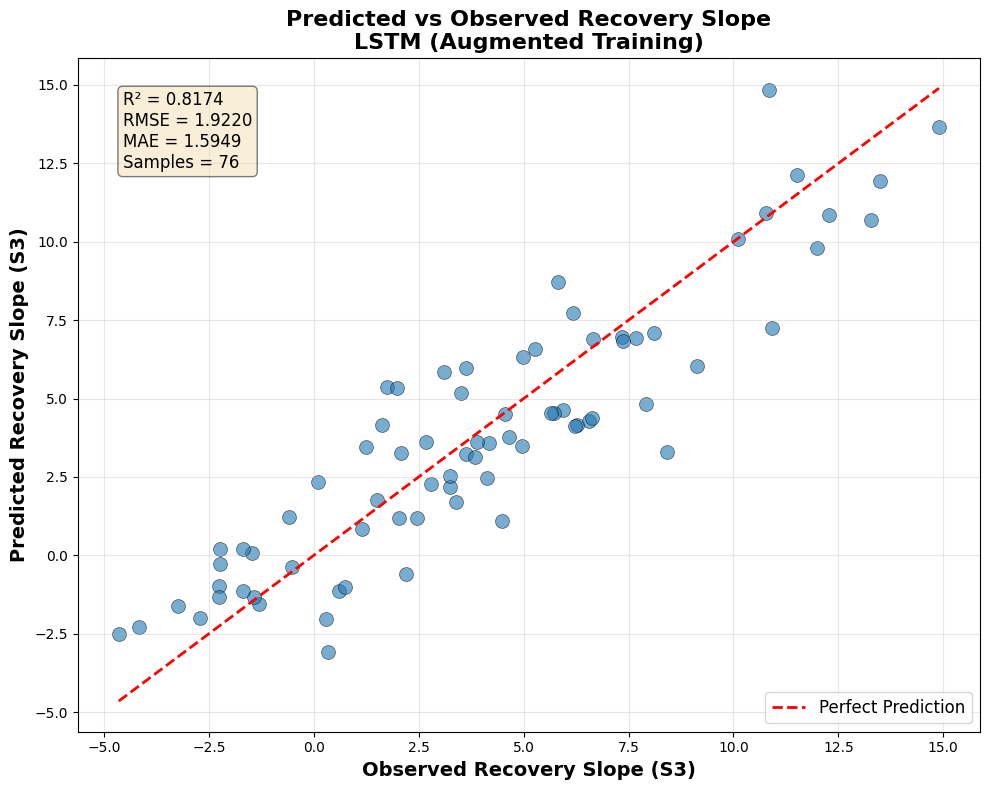

Best Model: LSTM
R² Score: 0.8174
RMSE: 1.9220
MAE: 1.5949


In [12]:
# Scatter Plot: Predicted vs Observed Recovery Slope (Best Model)

# Get best model name and its predictions
best_model_name = comparison_df.loc[comparison_df['R2_Augmented'].idxmax(), 'Model']
best_model_preds = augmented_loocv_predictions[best_model_name]

# Create arrays for plotting
predicted_values = []
actual_values = []

for idx in range(len(y_unified)):
    predicted_values.append(best_model_preds[idx])
    actual_values.append(y_unified[idx])

predicted_values = np.array(predicted_values)
actual_values = np.array(actual_values)

# Calculate metrics for the plot
r2 = r2_score(actual_values, predicted_values)
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)

# Create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(actual_values, predicted_values, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

# Add diagonal line (perfect prediction)
min_val = min(actual_values.min(), predicted_values.min())
max_val = max(actual_values.max(), predicted_values.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Labels and title
plt.xlabel('Observed Recovery Slope (S3)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Recovery Slope (S3)', fontsize=14, fontweight='bold')
plt.title(f'Predicted vs Observed Recovery Slope\n{best_model_name} (Augmented Training)', 
          fontsize=16, fontweight='bold')

# Add metrics text box
textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE = {mae:.4f}\nSamples = {len(actual_values)}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best Model: {best_model_name}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Saving aug models (not necessary before deadline, skip if you want)

In [ ]:
# ============================================================================
# SAVE AUGMENTED MODELS (Final training on full augmented dataset)
# ============================================================================
print('='*70)
print('TRAINING AND SAVING FINAL MODELS ON AUGMENTED DATA')
print('='*70)

import pickle
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# This trains final models on ALL augmented data (no cross-validation)
# Much faster than LOOCV - should take ~5-10 minutes total

# Prepare sequence data for PyTorch models (needed for LSTM/GRU/BiLSTM)
X_sequence_aug = X_unified_augmented[:, :11].reshape(-1, 11, 1)
X_metadata_aug = X_unified_augmented[:, 11:]

# 1. LINEAR REGRESSION (Ridge)
print('\n1. Training final Ridge model...')
scaler_lr_aug = StandardScaler()
X_scaled_lr = scaler_lr_aug.fit_transform(X_unified_augmented)
final_lr_aug = Ridge(alpha=10.0)
final_lr_aug.fit(X_scaled_lr, y_unified_augmented)

lr_aug_path = os.path.join(MODELS_DIR, 'LR_unified_model_augmented.pkl')
lr_scaler_aug_path = os.path.join(MODELS_DIR, 'LR_unified_scaler_augmented.pkl')
with open(lr_aug_path, 'wb') as f:
    pickle.dump(final_lr_aug, f)
with open(lr_scaler_aug_path, 'wb') as f:
    pickle.dump(scaler_lr_aug, f)
print(f'✓ Saved: {lr_aug_path}')
print(f'✓ Saved: {lr_scaler_aug_path}')

# 2. RANDOM FOREST
print('\n2. Training final Random Forest model...')
scaler_rf_aug = StandardScaler()
X_scaled_rf = scaler_rf_aug.fit_transform(X_unified_augmented)
final_rf_aug = RandomForestRegressor(n_estimators=120, random_state=42, max_depth=12, min_samples_leaf=2)
final_rf_aug.fit(X_scaled_rf, y_unified_augmented)

rf_aug_path = os.path.join(MODELS_DIR, 'RF_unified_model_augmented.pkl')
rf_scaler_aug_path = os.path.join(MODELS_DIR, 'RF_unified_scaler_augmented.pkl')
with open(rf_aug_path, 'wb') as f:
    pickle.dump(final_rf_aug, f)
with open(rf_scaler_aug_path, 'wb') as f:
    pickle.dump(scaler_rf_aug, f)
print(f'✓ Saved: {rf_aug_path}')
print(f'✓ Saved: {rf_scaler_aug_path}')

# Prepare sequence data for PyTorch models
X_seq_all_aug = torch.FloatTensor(X_sequence_aug)
X_meta_all_aug = torch.FloatTensor(X_metadata_aug)
y_all_aug = torch.FloatTensor(y_unified_augmented)

# 3. LSTM
print('\n3. Training final LSTM model (1000 epochs)...')
final_lstm_aug = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(final_lstm_aug.parameters(), lr=0.01)

final_lstm_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_lstm_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

lstm_aug_path = os.path.join(MODELS_DIR, 'LSTM_unified_model_augmented.pth')
torch.save(final_lstm_aug.state_dict(), lstm_aug_path)
print(f'✓ Saved: {lstm_aug_path}')

# 4. GRU
print('\n4. Training final GRU model (1000 epochs)...')
final_gru_aug = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
optimizer = torch.optim.Adam(final_gru_aug.parameters(), lr=0.01)

final_gru_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_gru_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

gru_aug_path = os.path.join(MODELS_DIR, 'GRU_unified_model_augmented.pth')
torch.save(final_gru_aug.state_dict(), gru_aug_path)
print(f'✓ Saved: {gru_aug_path}')

# 5. BiLSTM
print('\n5. Training final BiLSTM model (1000 epochs)...')
final_bilstm_aug = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
optimizer = torch.optim.Adam(final_bilstm_aug.parameters(), lr=0.01)

final_bilstm_aug.train()
for epoch in range(1000):
    if (epoch + 1) % 200 == 0:
        print(f'  Epoch {epoch + 1}/1000')
    optimizer.zero_grad()
    outputs = final_bilstm_aug(X_seq_all_aug, X_meta_all_aug)
    loss = criterion(outputs.squeeze(), y_all_aug)
    loss.backward()
    optimizer.step()

bilstm_aug_path = os.path.join(MODELS_DIR, 'BiLSTM_unified_model_augmented.pth')
torch.save(final_bilstm_aug.state_dict(), bilstm_aug_path)
print(f'✓ Saved: {bilstm_aug_path}')

print('\n' + '='*70)
print('ALL AUGMENTED MODELS SAVED SUCCESSFULLY')
print('='*70)
print(f'Models saved to: {MODELS_DIR}/')
print('  - LR_unified_model_augmented.pkl')
print('  - RF_unified_model_augmented.pkl')
print('  - LSTM_unified_model_augmented.pth')
print('  - GRU_unified_model_augmented.pth')
print('  - BiLSTM_unified_model_augmented.pth')
print('='*70)

# Genotype Drought Scoring and Ranking (Run this)

RANKING COMPARISON: VALIDATION PREDICTIONS vs GROUND TRUTH

✓ Using validation predictions from: LSTM
✓ Validation R²: 0.8174

✓ Matched 16 genotypes between ground truth and predictions
Ground truth genotypes: 16
Predicted genotypes: 16

RANKING ACCURACY METRICS

📊 Spearman's Rank Correlation: 0.7147 (p-value: 1.8627e-03)
   Interpretation: 0.7147 → Strong positive correlation ✓

📊 Kendall's Tau: 0.5833 (p-value: 1.1426e-03)
   Interpretation: 79.2% of genotype pairs ranked in same order

📊 Top-K Accuracy:
   Top-3: 2/3 correct (66.7%)
   Top-5: 3/5 correct (60.0%)
   Top-10: 9/10 correct (90.0%)

📊 Mean Absolute Error (MAE) of Ranks: 2.50 positions
   Interpretation: On average, predictions are off by 2.50 rank positions


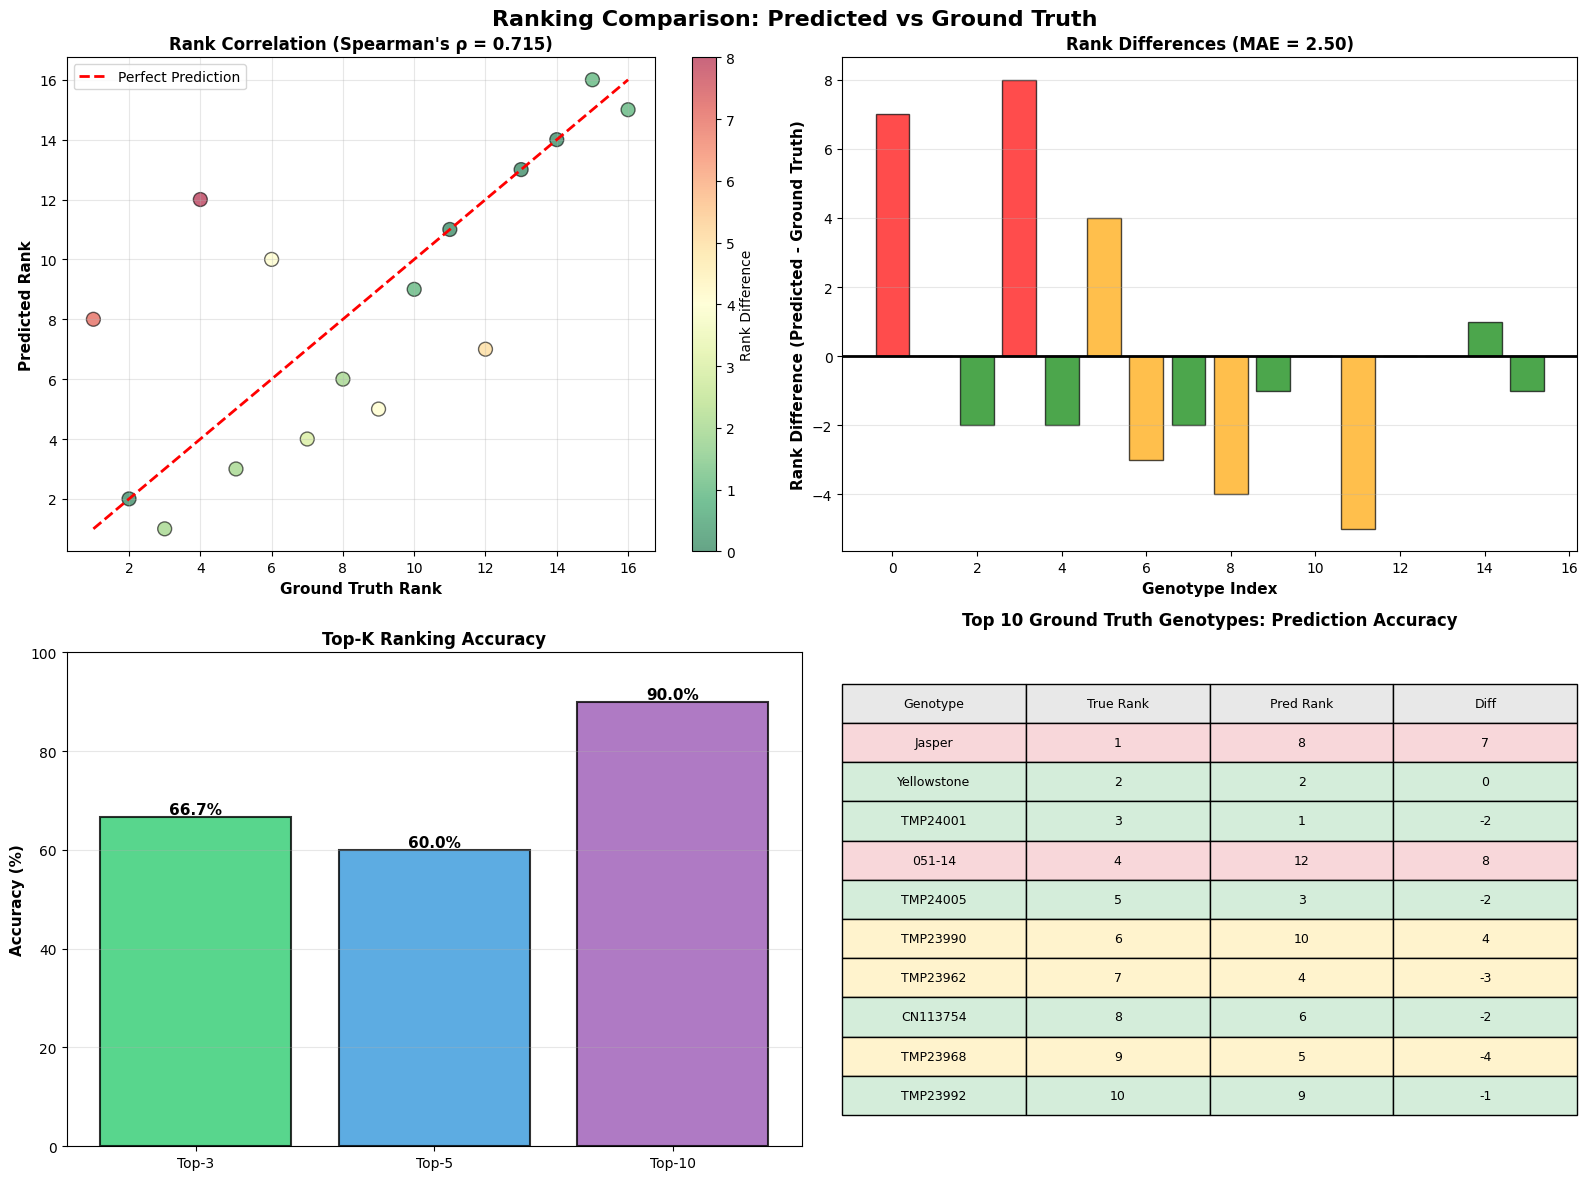


SUMMARY REPORT
Spearman's ρ:     0.7147 (closer to 1 = better)
Kendall's τ:      0.5833 (79.2% pairs in correct order)
MAE:              2.50 positions off on average
Top-3 Accuracy:  66.7%
Top-5 Accuracy:  60.0%
Top-10 Accuracy:  90.0%

✓ Full comparison saved in 'ranking_comparison_df' variable
✓ Source: LSTM validation predictions (R²=0.8174)
✓ Columns: Genotype, ground_truth_rank, predicted_rank, rank_difference, predicted_score


In [13]:
# ============================================================================
# RANKING ACCURACY EVALUATION: Compare Predicted vs Ground Truth Rankings
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# ============================================================================
# INPUT: Ground Truth Ranking (ordered list from best to worst)
# ============================================================================
# Replace this list with your actual ground truth ranking
ground_truth_ranking = [
    "Jasper", 
    "Yellowstone", 
    "TMP24001", 
    "051-14", 
    "TMP24005", 
    "TMP23990", 
    "TMP23962", 
    "CN113754",
    "TMP23968", 
    "TMP23992",
    "17CS1133",
    "Hoga",
    "TMP23969",
    "CAM241",
    "Blaine Creek",
    "CAM236"
    # Add all your genotypes in order from best (rank 1) to worst
]

print("="*70)
print("RANKING COMPARISON: VALIDATION PREDICTIONS vs GROUND TRUTH")
print("="*70)

# ============================================================================
# STEP 1: Prepare Data
# ============================================================================
# Create ground truth DataFrame with ranks
ground_truth_df = pd.DataFrame({
    'Genotype': ground_truth_ranking,
    'ground_truth_rank': range(1, len(ground_truth_ranking) + 1)
})

# Use validation-based rankings from best_augmented_validation_rankings
# This contains rankings from LOOCV predictions (more reliable)
predicted_df = best_augmented_validation_rankings[['Genotype', 'Rank', 'Predicted_Slope_Mean']].copy()
predicted_df.rename(columns={'Rank': 'predicted_rank', 'Predicted_Slope_Mean': 'predicted_score'}, inplace=True)

# Merge on genotype
ranking_comparison_df = pd.merge(ground_truth_df, predicted_df, on='Genotype', how='inner')
ranking_comparison_df['rank_difference'] = ranking_comparison_df['predicted_rank'] - ranking_comparison_df['ground_truth_rank']

print(f"\n✓ Using validation predictions from: {best_aug_model_name}")
print(f"✓ Validation R²: {best_aug_r2:.4f}")
print(f"\n✓ Matched {len(ranking_comparison_df)} genotypes between ground truth and predictions")
print(f"Ground truth genotypes: {len(ground_truth_ranking)}")
print(f"Predicted genotypes: {len(predicted_df)}")

if len(ranking_comparison_df) == 0:
    print("\n❌ ERROR: No matching genotypes found!")
    print("Please check that genotype names match exactly between ground truth and predictions.")
else:
    # ============================================================================
    # STEP 2: Calculate Metrics
    # ============================================================================
    print("\n" + "="*70)
    print("RANKING ACCURACY METRICS")
    print("="*70)
    
    # 1. Spearman's Rank Correlation
    spearman_corr, spearman_pval = spearmanr(ranking_comparison_df['ground_truth_rank'], 
                                              ranking_comparison_df['predicted_rank'])
    print(f"\n📊 Spearman's Rank Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")
    print(f"   Interpretation: {spearman_corr:.4f} → ", end="")
    if spearman_corr > 0.9:
        print("Excellent agreement! 🎉")
    elif spearman_corr > 0.7:
        print("Strong positive correlation ✓")
    elif spearman_corr > 0.5:
        print("Moderate positive correlation")
    elif spearman_corr > 0.3:
        print("Weak positive correlation")
    else:
        print("Poor correlation")
    
    # 2. Kendall's Tau
    kendall_corr, kendall_pval = kendalltau(ranking_comparison_df['ground_truth_rank'], 
                                             ranking_comparison_df['predicted_rank'])
    print(f"\n📊 Kendall's Tau: {kendall_corr:.4f} (p-value: {kendall_pval:.4e})")
    concordant_pairs = (1 + kendall_corr) / 2 * 100
    print(f"   Interpretation: {concordant_pairs:.1f}% of genotype pairs ranked in same order")
    
    # 3. Top-K Accuracy
    print(f"\n📊 Top-K Accuracy:")
    k_values = [3, 5, 10]
    top_k_results = {}
    
    for k in k_values:
        if k > len(ranking_comparison_df):
            continue
        top_k_ground_truth = set(ranking_comparison_df.nsmallest(k, 'ground_truth_rank')['Genotype'])
        top_k_predicted = set(ranking_comparison_df.nsmallest(k, 'predicted_rank')['Genotype'])
        overlap = len(top_k_ground_truth.intersection(top_k_predicted))
        accuracy = overlap / k * 100
        top_k_results[k] = accuracy
        print(f"   Top-{k}: {overlap}/{k} correct ({accuracy:.1f}%)")
    
    # 4. Mean Absolute Error of Ranks
    mae_rank = np.mean(np.abs(ranking_comparison_df['rank_difference']))
    print(f"\n📊 Mean Absolute Error (MAE) of Ranks: {mae_rank:.2f} positions")
    print(f"   Interpretation: On average, predictions are off by {mae_rank:.2f} rank positions")
    
    # ============================================================================
    # STEP 3: Visualizations
    # ============================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Ranking Comparison: Predicted vs Ground Truth', fontsize=16, fontweight='bold')
    
    # Plot 1: Scatter Plot - Predicted vs Ground Truth Ranks
    ax1 = axes[0, 0]
    scatter = ax1.scatter(ranking_comparison_df['ground_truth_rank'], 
                         ranking_comparison_df['predicted_rank'],
                         s=100, alpha=0.6, c=np.abs(ranking_comparison_df['rank_difference']),
                         cmap='RdYlGn_r', edgecolors='black', linewidth=1)
    
    # Perfect prediction line
    max_rank = max(ranking_comparison_df['ground_truth_rank'].max(), ranking_comparison_df['predicted_rank'].max())
    ax1.plot([1, max_rank], [1, max_rank], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax1.set_xlabel('Ground Truth Rank', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Predicted Rank', fontsize=11, fontweight='bold')
    ax1.set_title(f"Rank Correlation (Spearman's ρ = {spearman_corr:.3f})", fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax1, label='Rank Difference')
    
    # Plot 2: Rank Difference Distribution
    ax2 = axes[0, 1]
    colors = ['green' if abs(x) <= 2 else 'orange' if abs(x) <= 5 else 'red' 
              for x in ranking_comparison_df['rank_difference']]
    ax2.bar(range(len(ranking_comparison_df)), ranking_comparison_df['rank_difference'], 
           color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Genotype Index', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Rank Difference (Predicted - Ground Truth)', fontsize=11, fontweight='bold')
    ax2.set_title(f'Rank Differences (MAE = {mae_rank:.2f})', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Plot 3: Top-K Accuracy Bar Chart
    ax3 = axes[1, 0]
    k_labels = [f'Top-{k}' for k in top_k_results.keys()]
    k_accuracies = list(top_k_results.values())
    bars = ax3.bar(k_labels, k_accuracies, color=['#2ecc71', '#3498db', '#9b59b6'], 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    ax3.set_title('Top-K Ranking Accuracy', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 100)
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Plot 4: Side-by-Side Comparison Table (Top 10)
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    top_10_comparison = ranking_comparison_df.nsmallest(10, 'ground_truth_rank')[
        ['Genotype', 'ground_truth_rank', 'predicted_rank', 'rank_difference']
    ].copy()
    top_10_comparison.columns = ['Genotype', 'True Rank', 'Pred Rank', 'Diff']
    
    # Color code the differences
    cell_colors = []
    for _, row in top_10_comparison.iterrows():
        diff = abs(row['Diff'])
        if diff <= 2:
            row_color = ['#d4edda'] * 4  # Light green
        elif diff <= 5:
            row_color = ['#fff3cd'] * 4  # Light yellow
        else:
            row_color = ['#f8d7da'] * 4  # Light red
        cell_colors.append(row_color)
    
    table = ax4.table(cellText=top_10_comparison.values,
                     colLabels=top_10_comparison.columns,
                     cellLoc='center',
                     loc='center',
                     cellColours=cell_colors,
                     colColours=['#e8e8e8'] * 4)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax4.set_title('Top 10 Ground Truth Genotypes: Prediction Accuracy', 
                 fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================================================
    # STEP 4: Summary Report
    # ============================================================================
    print("\n" + "="*70)
    print("SUMMARY REPORT")
    print("="*70)
    print(f"Spearman's ρ:     {spearman_corr:.4f} (closer to 1 = better)")
    print(f"Kendall's τ:      {kendall_corr:.4f} ({concordant_pairs:.1f}% pairs in correct order)")
    print(f"MAE:              {mae_rank:.2f} positions off on average")
    for k, acc in top_k_results.items():
        print(f"Top-{k} Accuracy:  {acc:.1f}%")
    print("="*70)
    
    # Save comparison to DataFrame for further analysis
    print("\n✓ Full comparison saved in 'ranking_comparison_df' variable")
    print(f"✓ Source: {best_aug_model_name} validation predictions (R²={best_aug_r2:.4f})")
    print("✓ Columns: Genotype, ground_truth_rank, predicted_rank, rank_difference, predicted_score")

# NOT NECESSARY: Testing final models on Original Dataset

In [ ]:
# ============================================================================
# STANDALONE: Load and Test Best Model on Original Dataset
# ============================================================================
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import os
import pickle

print("="*70)
print("LOADING AND TESTING BEST MODEL ON ORIGINAL DATASET")
print("="*70)

# Define Model Architectures
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_seq, x_meta):
        out, _ = self.gru(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, metadata_size):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc1 = nn.Linear(hidden_size * 2 + metadata_size, 32)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x_seq, x_meta):
        out, _ = self.lstm(x_seq)
        out = out[:, -1, :]
        x = torch.cat((out, x_meta), dim=1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

# Check that original dataset exists
if 'X_unified' not in globals() or 'y_unified' not in globals():
    print("❌ ERROR: Original dataset (X_unified, y_unified) not found!")
    print("Please run the dataset preparation cell first (cell that creates unified dataset).")
else:
    # Determine the best model from test results
    if 'best_original' not in locals() and 'best_augmented' not in locals():
        print("⚠ WARNING: No best model information found. Using LSTM augmented as default.")
        best_model_name = 'LSTM'
        model_type = 'augmented'
        best_model_r2 = None
    else:
        # Compare best_original and best_augmented
        if 'best_original' in locals() and 'best_augmented' in locals():
            r2_orig = best_original['R²_Original']
            r2_aug = best_augmented['R²_Augmented']
            
            if r2_aug > r2_orig:
                best_model_name = best_augmented['Model']
                best_model_r2 = r2_aug
                model_type = 'augmented'
            else:
                best_model_name = best_original['Model']
                best_model_r2 = r2_orig
                model_type = 'original'
        elif 'best_augmented' in locals():
            best_model_name = best_augmented['Model']
            best_model_r2 = best_augmented['R²_Augmented']
            model_type = 'augmented'
        else:
            best_model_name = best_original['Model']
            best_model_r2 = best_original['R²_Original']
            model_type = 'original'
    
    print(f"📊 Best Model: {best_model_name}")
    if best_model_r2 is not None:
        print(f"   Test R² Score: {best_model_r2:.4f} ({model_type})")
    print(f"\n🔬 Testing BOTH training strategies on original dataset (76 samples)\n")
    
    # Model paths
    MODELS_DIR = 'models'
    is_sequence_model = best_model_name in ['LSTM', 'GRU', 'BiLSTM']
    
    # Prepare data
    y_true = y_unified
    
    # Dictionary to store results for both models
    results = {}
    
    # Test both original and augmented versions
    for train_type in ['original', 'augmented']:
        print("="*70)
        print(f"Testing {best_model_name} trained on {train_type.upper()} data")
        print("="*70)
        
        model_suffix = '_augmented' if train_type == 'augmented' else ''
        
        # Load and test model
        if is_sequence_model:
            # Load PyTorch sequence model
            model_filename = f"{best_model_name}_unified_model{model_suffix}.pth"
            model_path = os.path.join(MODELS_DIR, model_filename)
            
            if not os.path.exists(model_path):
                print(f"❌ ERROR: Model not found at {model_path}\n")
                results[train_type] = None
                continue
            else:
                print(f"✓ Model found: {model_path}")
                
                # Prepare sequence data
                X_sequence = X_unified[:, :11].reshape(-1, 11, 1)
                X_metadata = X_unified[:, 11:]
                X_seq_tensor = torch.FloatTensor(X_sequence)
                X_meta_tensor = torch.FloatTensor(X_metadata)
                
                # Load model
                print(f"Loading {best_model_name} model...")
                if best_model_name == 'LSTM':
                    test_model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
                elif best_model_name == 'GRU':
                    test_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
                elif best_model_name == 'BiLSTM':
                    test_model = BiLSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1, metadata_size=19)
                
                test_model.load_state_dict(torch.load(model_path))
                test_model.eval()
                print("✓ Model loaded successfully")
                
                # Make predictions
                print("Making predictions on original dataset...")
                with torch.no_grad():
                    y_pred_tensor = test_model(X_seq_tensor, X_meta_tensor)
                    y_pred = y_pred_tensor.squeeze().numpy()
        else:
            # Load sklearn tabular model
            if best_model_name.startswith('Linear'):
                model_filename = f"LR_unified_model{model_suffix}.pkl"
                scaler_filename = f"LR_unified_scaler{model_suffix}.pkl"
            elif best_model_name.startswith('Random'):
                model_filename = f"RF_unified_model{model_suffix}.pkl"
                scaler_filename = f"RF_unified_scaler{model_suffix}.pkl"
            
            model_path = os.path.join(MODELS_DIR, model_filename)
            scaler_path = os.path.join(MODELS_DIR, scaler_filename)
            
            if not os.path.exists(model_path):
                print(f"❌ ERROR: Model not found at {model_path}\n")
                results[train_type] = None
                continue
            else:
                print(f"✓ Model found: {model_path}")
                
                # Load model and scaler
                print(f"Loading {best_model_name} model...")
                with open(model_path, 'rb') as f:
                    test_model = pickle.load(f)
                with open(scaler_path, 'rb') as f:
                    test_scaler = pickle.load(f)
                print("✓ Model loaded successfully")
                
                # Make predictions
                print("Making predictions on original dataset...")
                X_scaled = test_scaler.transform(X_unified)
                y_pred = test_model.predict(X_scaled)
        
        # Calculate metrics
        r2 = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        max_error = np.max(np.abs(y_true - y_pred))
        
        # Store results
        results[train_type] = {
            'predictions': y_pred,
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'mse': mse,
            'mape': mape,
            'max_error': max_error,
            'mean_pred': y_pred.mean(),
            'std_pred': y_pred.std()
        }
        
        # Print individual results
        print(f"\n📊 Results for {train_type.upper()} training:")
        print(f"  R² Score:     {r2:.4f}")
        print(f"  RMSE:         {rmse:.6f}")
        print(f"  MAE:          {mae:.6f}")
        print(f"  MAPE:         {mape:.2f}%")
        print(f"  Max Error:    {max_error:.6f}\n")
    
    # Comparative analysis
    print("\n" + "="*70)
    print("COMPARATIVE PERFORMANCE ANALYSIS")
    print("="*70)
    print(f"Model:                {best_model_name}")
    print(f"Test Dataset:         Original (76 samples)")
    print("="*70)
    
    if results['original'] is not None and results['augmented'] is not None:
        print(f"\n{'Metric':<20} {'Original Train':<18} {'Augmented Train':<18} {'Improvement':<15}")
        print("-"*70)
        
        r2_orig = results['original']['r2']
        r2_aug = results['augmented']['r2']
        r2_diff = r2_aug - r2_orig
        r2_pct = (r2_diff / abs(r2_orig)) * 100 if r2_orig != 0 else 0
        print(f"{'R² Score':<20} {r2_orig:<18.4f} {r2_aug:<18.4f} {r2_diff:+.4f} ({r2_pct:+.1f}%)")
        
        rmse_orig = results['original']['rmse']
        rmse_aug = results['augmented']['rmse']
        rmse_diff = rmse_orig - rmse_aug  # Lower is better, so original - augmented
        rmse_pct = (rmse_diff / rmse_orig) * 100 if rmse_orig != 0 else 0
        print(f"{'RMSE':<20} {rmse_orig:<18.6f} {rmse_aug:<18.6f} {rmse_diff:+.6f} ({rmse_pct:+.1f}%)")
        
        mae_orig = results['original']['mae']
        mae_aug = results['augmented']['mae']
        mae_diff = mae_orig - mae_aug  # Lower is better
        mae_pct = (mae_diff / mae_orig) * 100 if mae_orig != 0 else 0
        print(f"{'MAE':<20} {mae_orig:<18.6f} {mae_aug:<18.6f} {mae_diff:+.6f} ({mae_pct:+.1f}%)")
        
        mape_orig = results['original']['mape']
        mape_aug = results['augmented']['mape']
        mape_diff = mape_orig - mape_aug
        print(f"{'MAPE':<20} {mape_orig:<18.2f}% {mape_aug:<18.2f}% {mape_diff:+.2f}%")
        
        print("="*70)
        
        # Determine winner
        print("\n🏆 VERDICT:")
        if r2_aug > r2_orig:
            improvement = r2_aug - r2_orig
            print(f"  ✓ AUGMENTED training performs BETTER")
            print(f"    - R² improvement: +{improvement:.4f} ({r2_pct:+.1f}%)")
            print(f"    - Training on augmented data improves generalization to original data")
            winner = 'augmented'
        elif r2_orig > r2_aug:
            decline = r2_orig - r2_aug
            print(f"  ✓ ORIGINAL training performs BETTER")
            print(f"    - R² advantage: +{decline:.4f} ({-r2_pct:+.1f}%)")
            print(f"    - Direct training on original data achieves better performance")
            winner = 'original'
        else:
            print(f"  = Both training strategies perform EQUALLY")
            winner = 'tie'
        
        # Store results in variables for further use
        best_model_original_predictions = results['original']['predictions']
        best_model_augmented_predictions = results['augmented']['predictions']
        best_model_original_actuals = y_true
        best_model_original_r2 = results['original']['r2']
        best_model_augmented_r2 = results['augmented']['r2']
        best_model_original_rmse = results['original']['rmse']
        best_model_augmented_rmse = results['augmented']['rmse']
        best_model_original_mae = results['original']['mae']
        best_model_augmented_mae = results['augmented']['mae']
        best_model_comparison_winner = winner
        
        print("\n✓ Results saved in variables:")
        print("  - best_model_original_predictions")
        print("  - best_model_augmented_predictions")
        print("  - best_model_original_actuals")
        print("  - best_model_original_r2, best_model_augmented_r2")
        print("  - best_model_original_rmse, best_model_augmented_rmse")
        print("  - best_model_original_mae, best_model_augmented_mae")
        print("  - best_model_comparison_winner")
    else:
        print("⚠ WARNING: Could not compare models - one or both models not found")
        print("="*70)